# Tiền xử lý dữ liệu chuỗi thời gian cho mô hình GDP

Notebook này thực hiện các bước tiền xử lý dữ liệu kinh tế vĩ mô để phục vụ phân tích và mô hình hóa chuỗi thời gian.

Các mục tiêu chính:
- Kiểm tra cấu trúc dữ liệu và tần suất thời gian
- Xử lý giá trị thiếu theo đúng bản chất từng biến
- Biến đổi dữ liệu, đặc biệt là `log(GDP)` khi GDP có xu hướng tăng phi tuyến
- Tạo thêm các biến trễ (lag features) để hỗ trợ mô hình
- Chuẩn hóa biến đầu vào cho các mô hình machine learning

In [21]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")

## Đọc dữ liệu và kiểm tra sơ bộ

Ở bước này, dữ liệu được đọc từ file CSV, chuyển cột thời gian về đúng định dạng `datetime`, sau đó sắp xếp theo thứ tự thời gian tăng dần.

Việc kiểm tra sơ bộ nhằm trả lời các câu hỏi:
- Có bao nhiêu quan sát?
- Tên biến có đúng như kỳ vọng không?
- Có giá trị thiếu hay không?
- Kiểu dữ liệu của từng cột đã phù hợp chưa?

In [22]:
DATA_PATH = "secondary_data_cleaned.csv"

df = pd.read_csv(DATA_PATH)
df["Year"] = pd.to_datetime(df["Year"])
df = df.sort_values("Year").reset_index(drop=True)

print("Kích thước dữ liệu:", df.shape)
display(df.head())
display(df.info())
display(df.isna().sum())

Kích thước dữ liệu: (120, 10)


,Year,GDP_Raw,Inflation,Interest_Rate,FDI_pct_GDP,Investment_pct_GDP,Export_pct_GDP,Unemployment_Rate,Gov_Spending_pct_GDP,GDP_Growth
0,1995-04-01,20.50,3.537,3.577,5.488,31.137,76.943,2.524,20.262,2.500
1,1995-07-01,21.00,3.825,3.471,5.075,31.661,78.188,2.686,19.803,2.439
2,1995-10-01,21.50,4.113,3.366,4.662,32.185,79.433,2.847,19.345,2.381
3,1996-01-01,22.00,4.401,3.260,4.249,32.710,80.678,3.008,18.886,2.326
4,1996-04-01,22.55,4.292,4.144,4.182,32.017,83.121,3.042,18.842,2.500


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  120 non-null    datetime64[ns]
 1   GDP_Raw               120 non-null    float64       
 2   Inflation             120 non-null    float64       
 3   Interest_Rate         120 non-null    float64       
 4   FDI_pct_GDP           120 non-null    float64       
 5   Investment_pct_GDP    120 non-null    float64       
 6   Export_pct_GDP        120 non-null    float64       
 7   Unemployment_Rate     120 non-null    float64       
 8   Gov_Spending_pct_GDP  120 non-null    float64       
 9   GDP_Growth            120 non-null    float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 9.5 KB


None

Year                    0
GDP_Raw                 0
Inflation               0
Interest_Rate           0
FDI_pct_GDP             0
Investment_pct_GDP      0
Export_pct_GDP          0
Unemployment_Rate       0
Gov_Spending_pct_GDP    0
GDP_Growth              0
dtype: int64

## Kiểm tra tần suất thời gian và tái lập trục quý chuẩn

Vì đây là dữ liệu chuỗi thời gian, việc bảo đảm trục thời gian liên tục là rất quan trọng.

Ta tạo lại một `quarterly index` đầy đủ từ thời điểm đầu đến thời điểm cuối của mẫu.  
Nếu trong dữ liệu bị thiếu quý nào đó, bước này sẽ làm lộ ra khoảng trống để xử lý ở bước kế tiếp.

Ý nghĩa:
- Giúp phát hiện quý bị thiếu
- Giúp nội suy hoặc điền dữ liệu đúng theo thứ tự thời gian
- Giúp các mô hình time series hoạt động ổn định hơn

In [23]:
data = df.copy().set_index("Year")
data.index.name = "Date"

full_index = pd.date_range(data.index.min(), data.index.max(), freq="QS")
data = data.reindex(full_index)

print("Số dòng sau khi reindex:", len(data))
print("Số giá trị thiếu sau khi dựng full quarterly index:")
display(data.isna().sum())
display(data.head())

Số dòng sau khi reindex: 120
Số giá trị thiếu sau khi dựng full quarterly index:


GDP_Raw                 0
Inflation               0
Interest_Rate           0
FDI_pct_GDP             0
Investment_pct_GDP      0
Export_pct_GDP          0
Unemployment_Rate       0
Gov_Spending_pct_GDP    0
GDP_Growth              0
dtype: int64

,GDP_Raw,Inflation,Interest_Rate,FDI_pct_GDP,Investment_pct_GDP,Export_pct_GDP,Unemployment_Rate,Gov_Spending_pct_GDP,GDP_Growth
1995-04-01,20.50,3.537,3.577,5.488,31.137,76.943,2.524,20.262,2.500
1995-07-01,21.00,3.825,3.471,5.075,31.661,78.188,2.686,19.803,2.439
1995-10-01,21.50,4.113,3.366,4.662,32.185,79.433,2.847,19.345,2.381
1996-01-01,22.00,4.401,3.260,4.249,32.710,80.678,3.008,18.886,2.326
1996-04-01,22.55,4.292,4.144,4.182,32.017,83.121,3.042,18.842,2.500


## Xử lý giá trị thiếu

Quy tắc xử lý được dùng như sau:

- `GDP_Raw`: dùng **forward-fill**  
  Vì GDP là biến mức, việc lấy giá trị gần nhất về phía trước hợp lý hơn trong nhiều trường hợp thiếu dữ liệu.

- Các biến còn lại: dùng **linear interpolation**  
  Phù hợp với các biến tỷ lệ hoặc chỉ số như lạm phát, lãi suất, đầu tư/GDP, xuất khẩu/GDP,...

Dù bộ dữ liệu hiện tại gần như không có thiếu, bước này vẫn cần giữ để notebook có thể tái sử dụng cho dữ liệu mới.

In [24]:
data["GDP_Raw"] = data["GDP_Raw"].ffill()

for col in data.columns:
    if col != "GDP_Raw":
        data[col] = data[col].interpolate(method="linear")

print("Giá trị thiếu sau xử lý:")
display(data.isna().sum())
display(data.head())

Giá trị thiếu sau xử lý:


GDP_Raw                 0
Inflation               0
Interest_Rate           0
FDI_pct_GDP             0
Investment_pct_GDP      0
Export_pct_GDP          0
Unemployment_Rate       0
Gov_Spending_pct_GDP    0
GDP_Growth              0
dtype: int64

,GDP_Raw,Inflation,Interest_Rate,FDI_pct_GDP,Investment_pct_GDP,Export_pct_GDP,Unemployment_Rate,Gov_Spending_pct_GDP,GDP_Growth
1995-04-01,20.50,3.537,3.577,5.488,31.137,76.943,2.524,20.262,2.500
1995-07-01,21.00,3.825,3.471,5.075,31.661,78.188,2.686,19.803,2.439
1995-10-01,21.50,4.113,3.366,4.662,32.185,79.433,2.847,19.345,2.381
1996-01-01,22.00,4.401,3.260,4.249,32.710,80.678,3.008,18.886,2.326
1996-04-01,22.55,4.292,4.144,4.182,32.017,83.121,3.042,18.842,2.500


## Hàm quy đổi tần suất dữ liệu (tùy chọn)

Trong một số trường hợp, dữ liệu từ nhiều nguồn có thể không cùng tần suất:
- GDP theo năm
- CPI theo tháng
- Lãi suất theo quý

Khi đó cần quy đổi về cùng tần suất trước khi mô hình hóa.

Nguyên tắc thường dùng:
- GDP: có thể lấy trung bình năm hoặc giá trị cuối năm
- CPI, lãi suất, các biến tỷ lệ: thường lấy trung bình năm

Với file hiện tại, dữ liệu đã là theo quý nên phần này chỉ để dự phòng.

In [25]:
def to_annual(df_quarterly, gdp_rule="mean", pct_rule="mean"):
    annual = pd.DataFrame(index=pd.date_range(df_quarterly.index.min(), df_quarterly.index.max(), freq="YS"))
    
    if gdp_rule == "last":
        annual["GDP_Raw"] = df_quarterly["GDP_Raw"].resample("YS").last()
    else:
        annual["GDP_Raw"] = df_quarterly["GDP_Raw"].resample("YS").mean()
    
    other_cols = [c for c in df_quarterly.columns if c != "GDP_Raw"]
    for c in other_cols:
        if pct_rule == "last":
            annual[c] = df_quarterly[c].resample("YS").last()
        else:
            annual[c] = df_quarterly[c].resample("YS").mean()
    
    return annual

# Ví dụ nếu sau này cần dùng:
# annual_data = to_annual(data, gdp_rule="mean", pct_rule="mean")
# display(annual_data.head())

## Biến đổi dữ liệu và tạo biến mới

Ở bước này, ta tạo các biến phục vụ phân tích và mô hình hóa:

### 1. Log-transform cho GDP
GDP thường có xu hướng tăng phi tuyến hoặc gần dạng hàm mũ.  
Do đó, sử dụng hàm log, giúp:
- làm chuỗi ổn định hơn
- giảm độ lệch
- hỗ trợ các mô hình time series tốt hơn

### 2. Tính lại tăng trưởng GDP
Ta tự tính:
- tăng trưởng quý so với quý trước
- tăng trưởng năm so với cùng kỳ năm trước

Điều này giúp bảo đảm tính nhất quán với `GDP_Raw`.

### 3. Tạo biến trễ
Lạm phát và lãi suất thường tác động đến GDP với độ trễ, nên ta tạo thêm các biến lag 1 và lag 2.

In [26]:
data["log_GDP"] = np.log(data["GDP_Raw"])
data["GDP_qoq_pct_recalc"] = data["GDP_Raw"].pct_change() * 100
data["GDP_yoy_pct_recalc"] = data["GDP_Raw"].pct_change(4) * 100

data["Inflation_lag1"] = data["Inflation"].shift(1)
data["Inflation_lag2"] = data["Inflation"].shift(2)
data["Interest_Rate_lag1"] = data["Interest_Rate"].shift(1)
data["Interest_Rate_lag2"] = data["Interest_Rate"].shift(2)

data["log_GDP_diff1"] = data["log_GDP"].diff()
data["log_GDP_diff4"] = data["log_GDP"].diff(4)

display(data.head(8))

,GDP_Raw,Inflation,Interest_Rate,FDI_pct_GDP,Investment_pct_GDP,Export_pct_GDP,Unemployment_Rate,Gov_Spending_pct_GDP,GDP_Growth,log_GDP,GDP_qoq_pct_recalc,GDP_yoy_pct_recalc,Inflation_lag1,Inflation_lag2,Interest_Rate_lag1,Interest_Rate_lag2,log_GDP_diff1,log_GDP_diff4
1995-04-01,20.50,3.537,3.577,5.488,31.137,76.943,2.524,20.262,2.500,3.020425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-07-01,21.00,3.825,3.471,5.075,31.661,78.188,2.686,19.803,2.439,3.044522,2.439024,NaN,3.537,NaN,3.577,NaN,0.024098,NaN
1995-10-01,21.50,4.113,3.366,4.662,32.185,79.433,2.847,19.345,2.381,3.068053,2.380952,NaN,3.825,3.537,3.471,3.577,0.023530,NaN
1996-01-01,22.00,4.401,3.260,4.249,32.710,80.678,3.008,18.886,2.326,3.091042,2.325581,NaN,4.113,3.825,3.366,3.471,0.022990,NaN
1996-04-01,22.55,4.292,4.144,4.182,32.017,83.121,3.042,18.842,2.500,3.115735,2.500000,10.0,4.401,4.113,3.260,3.366,0.024693,0.09531
1996-07-01,23.10,4.183,5.028,4.116,31.324,85.564,3.075,18.797,2.439,3.139833,2.439024,10.0,4.292,4.401,4.144,3.260,0.024098,0.09531
1996-10-01,23.65,4.073,5.912,4.050,30.631,88.007,3.109,18.752,2.381,3.163363,2.380952,10.0,4.183,4.292,5.028,4.144,0.023530,0.09531
1997-01-01,24.20,3.964,6.796,3.983,29.938,90.450,3.142,18.708,2.326,3.186353,2.325581,10.0,4.073,4.183,5.912,5.028,0.022990,0.09531


## Kiểm tra lại cột tăng trưởng GDP

Nếu dữ liệu gốc đã có sẵn cột `GDP_Growth`, ta nên đối chiếu với tăng trưởng tự tính từ `GDP_Raw`.

Mục tiêu của bước này là kiểm tra:
- Dữ liệu tăng trưởng có nhất quán hay không
- Có sai lệch lớn giữa dữ liệu gốc và dữ liệu tính lại hay không

Nếu hai chuỗi gần như trùng nhau, có thể yên tâm dùng chuỗi tính lại trong phân tích.

In [27]:
compare_growth = pd.DataFrame({
    "GDP_Growth_original": data["GDP_Growth"],
    "GDP_Growth_recalc": data["GDP_qoq_pct_recalc"]
})

compare_growth["abs_diff"] = (compare_growth["GDP_Growth_original"] - compare_growth["GDP_Growth_recalc"]).abs()

display(compare_growth.head(10))
print("Sai lệch tuyệt đối trung bình:", compare_growth["abs_diff"].mean())
print("Tương quan:", compare_growth[["GDP_Growth_original", "GDP_Growth_recalc"]].corr().iloc[0, 1])

,GDP_Growth_original,GDP_Growth_recalc,abs_diff
1995-04-01,2.500,NaN,NaN
1995-07-01,2.439,2.439024,2.439024e-05
1995-10-01,2.381,2.380952,4.761905e-05
1996-01-01,2.326,2.325581,4.186047e-04
1996-04-01,2.500,2.500000,1.332268e-14
1996-07-01,2.439,2.439024,2.439024e-05
1996-10-01,2.381,2.380952,4.761905e-05
1997-01-01,2.326,2.325581,4.186047e-04
1997-04-01,2.500,2.500000,8.881784e-15
1997-07-01,2.439,2.439024,2.439024e-05


Sai lệch tuyệt đối trung bình: 0.0004606841337797204
Tương quan: 0.9999508209423886


## Phân tích khám phá dữ liệu (EDA)

Phần này giúp quan sát trực quan hành vi của các biến theo thời gian:
- GDP có tăng đều hay không
- Lạm phát biến động như thế nào
- Lãi suất có những giai đoạn tăng giảm rõ rệt hay không

Ngoài ra, các thống kê mô tả cơ bản giúp ta hình dung nhanh về phân phối và độ biến động của từng biến.

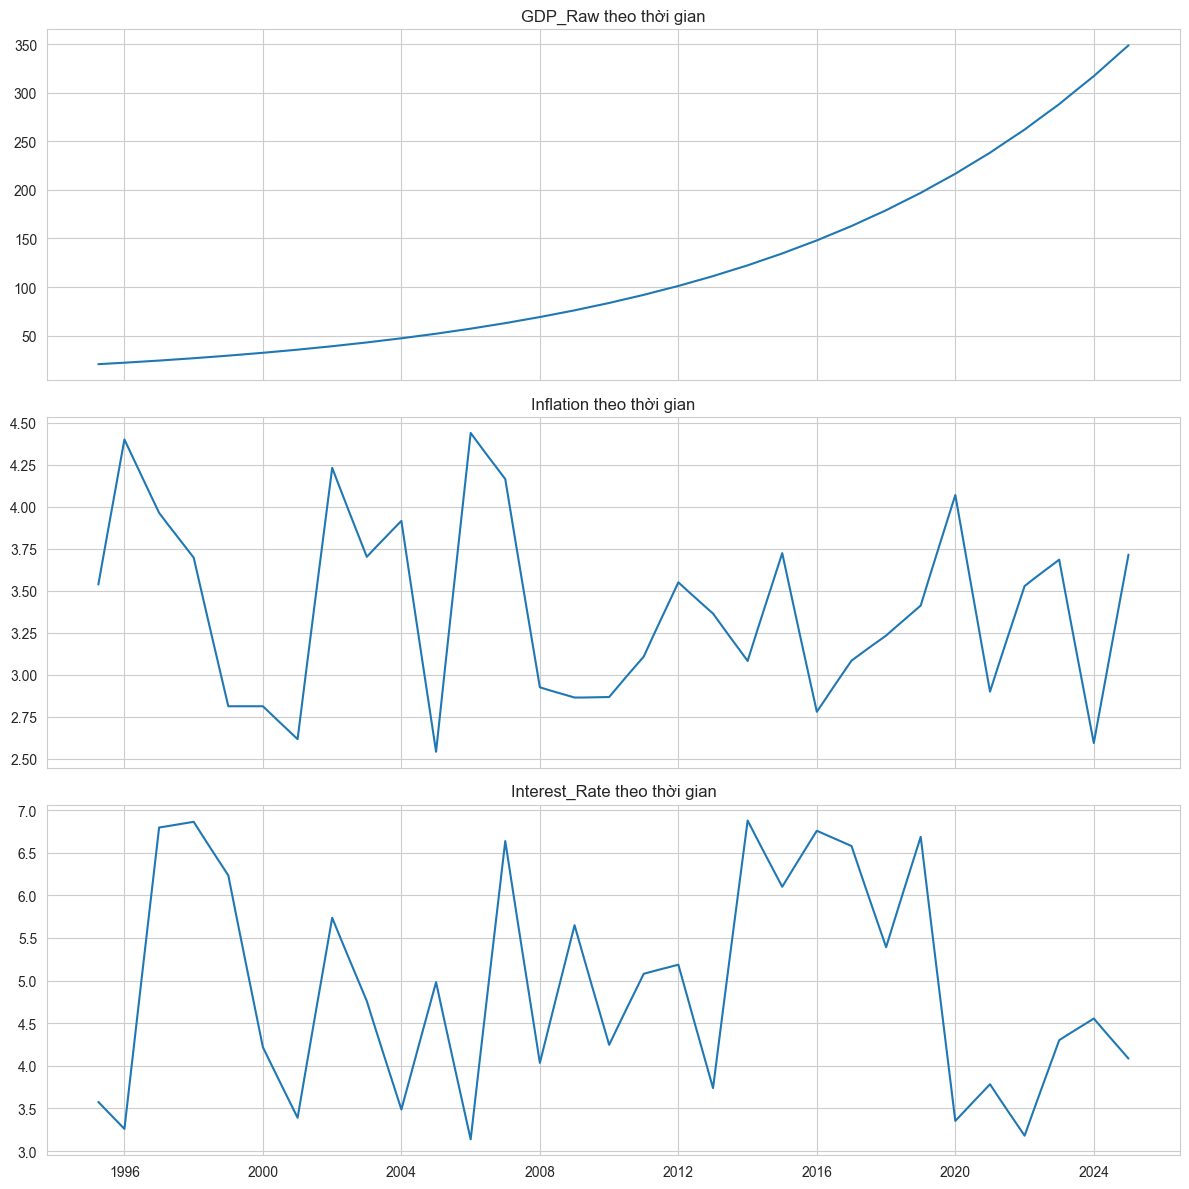

,count,mean,std,min,25%,50%,75%,max
GDP_Raw,120.0,116.516583,90.886175,20.500000,41.653500,84.589500,171.963500,348.988000
Inflation,120.0,3.386892,0.461911,2.541000,3.013250,3.365500,3.728250,4.440000
Interest_Rate,120.0,4.964833,1.105753,3.138000,4.078500,4.834000,5.930250,6.878000
FDI_pct_GDP,120.0,4.702725,0.853627,3.019000,4.040500,4.666000,5.500250,6.454000
Investment_pct_GDP,120.0,29.961458,2.573718,25.254000,27.837000,30.046500,32.167000,34.297000
Export_pct_GDP,120.0,81.503367,6.114123,70.174000,76.939000,80.791000,85.367000,94.641000
Unemployment_Rate,120.0,2.702750,0.321195,2.025000,2.453000,2.694000,2.949000,3.405000
Gov_Spending_pct_GDP,120.0,18.438817,1.810069,15.035000,17.107750,18.589500,19.850500,21.303000
GDP_Growth,120.0,2.411500,0.065135,2.326000,2.367250,2.410000,2.454250,2.500000
log_GDP,120.0,4.438008,0.828832,3.020425,3.729334,4.437734,5.147230,5.855038


In [28]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

axes[0].plot(data.index, data["GDP_Raw"])
axes[0].set_title("GDP_Raw theo thời gian")

axes[1].plot(data.index, data["Inflation"])
axes[1].set_title("Inflation theo thời gian")

axes[2].plot(data.index, data["Interest_Rate"])
axes[2].set_title("Interest_Rate theo thời gian")

plt.tight_layout()
plt.show()

display(data.describe().T)

## Scatter plot và tương quan giữa GDP với các biến vĩ mô

Ngoài việc quan sát chuỗi theo thời gian, ta cũng cần xem mối liên hệ trực quan giữa tăng trưởng GDP với lạm phát và lãi suất.

Vì GDP mức (`GDP_Raw`) và các biến như lạm phát/lãi suất có đơn vị rất khác nhau, việc dùng `GDP_yoy_pct_recalc` sẽ hợp lý hơn khi vẽ scatter plot.

Trong phần này:
- Vẽ scatter giữa tăng trưởng GDP và lạm phát
- Vẽ scatter giữa tăng trưởng GDP và lãi suất
- Tính ma trận tương quan Pearson và trực quan hóa bằng heatmap

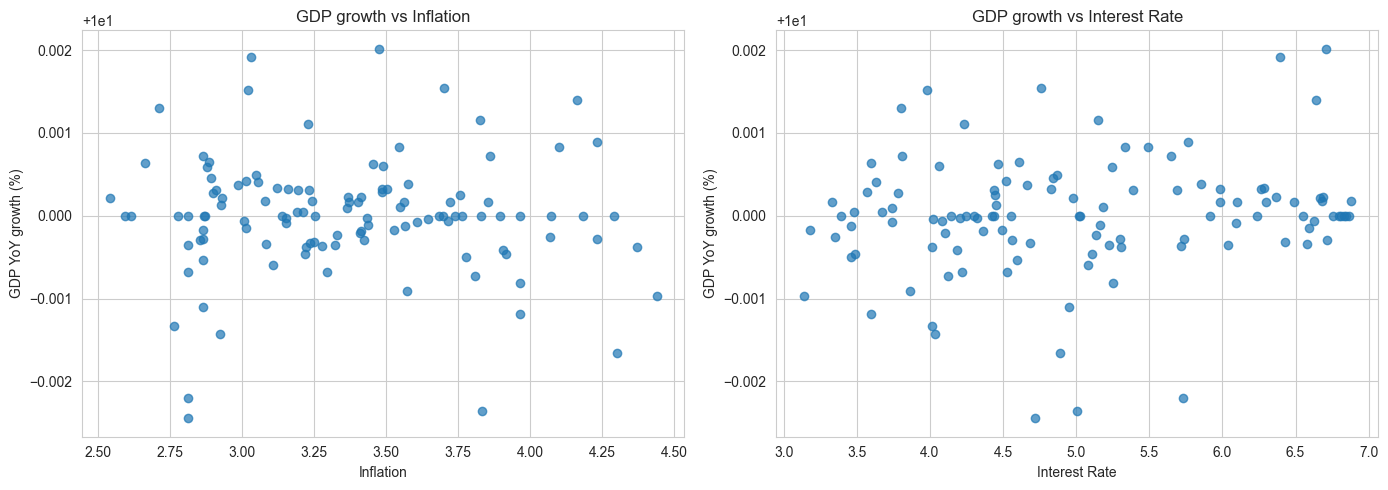

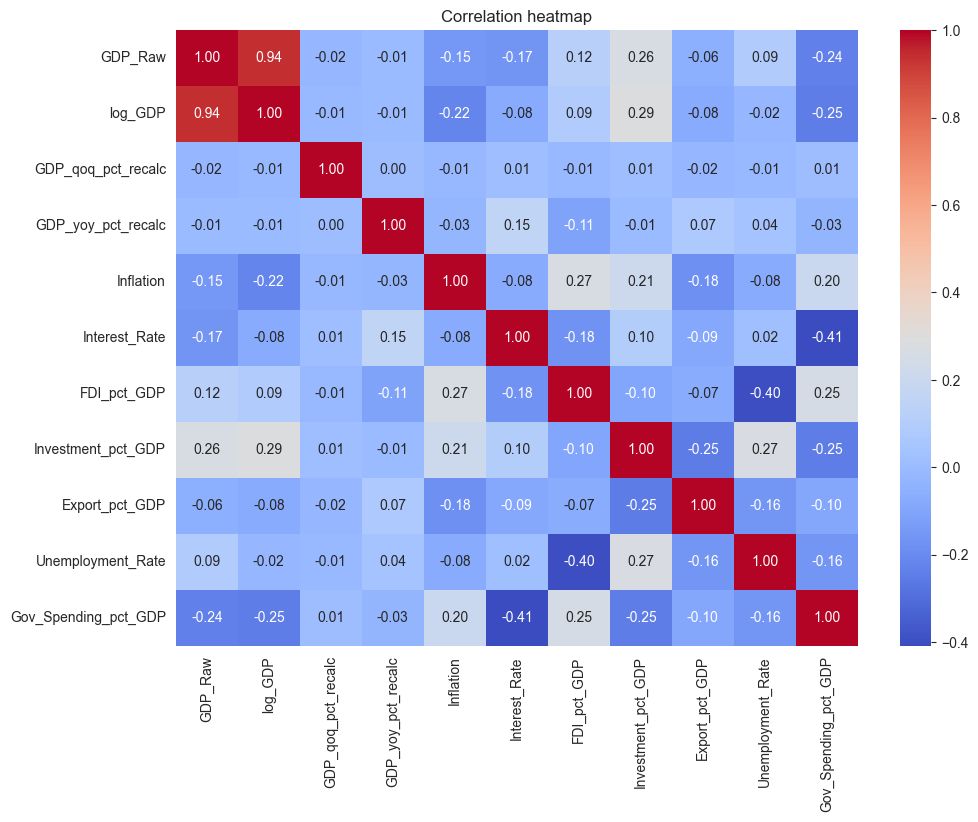

In [29]:
eda_cols = [
    "GDP_Raw", "log_GDP", "GDP_qoq_pct_recalc", "GDP_yoy_pct_recalc",
    "Inflation", "Interest_Rate", "FDI_pct_GDP", "Investment_pct_GDP",
    "Export_pct_GDP", "Unemployment_Rate", "Gov_Spending_pct_GDP"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(data["Inflation"], data["GDP_yoy_pct_recalc"], alpha=0.7)
axes[0].set_title("GDP growth vs Inflation")
axes[0].set_xlabel("Inflation")
axes[0].set_ylabel("GDP YoY growth (%)")

axes[1].scatter(data["Interest_Rate"], data["GDP_yoy_pct_recalc"], alpha=0.7)
axes[1].set_title("GDP growth vs Interest Rate")
axes[1].set_xlabel("Interest Rate")
axes[1].set_ylabel("GDP YoY growth (%)")

plt.tight_layout()
plt.show()

corr_matrix = data[eda_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

## Ma trận tương quan

Ma trận tương quan cho thấy mức độ liên hệ tuyến tính sơ bộ giữa các biến.

Bước này giúp:
- Xác định các biến có thể liên quan đến GDP
- Phát hiện khả năng đa cộng tuyến
- Hỗ trợ lựa chọn biến đầu vào cho mô hình

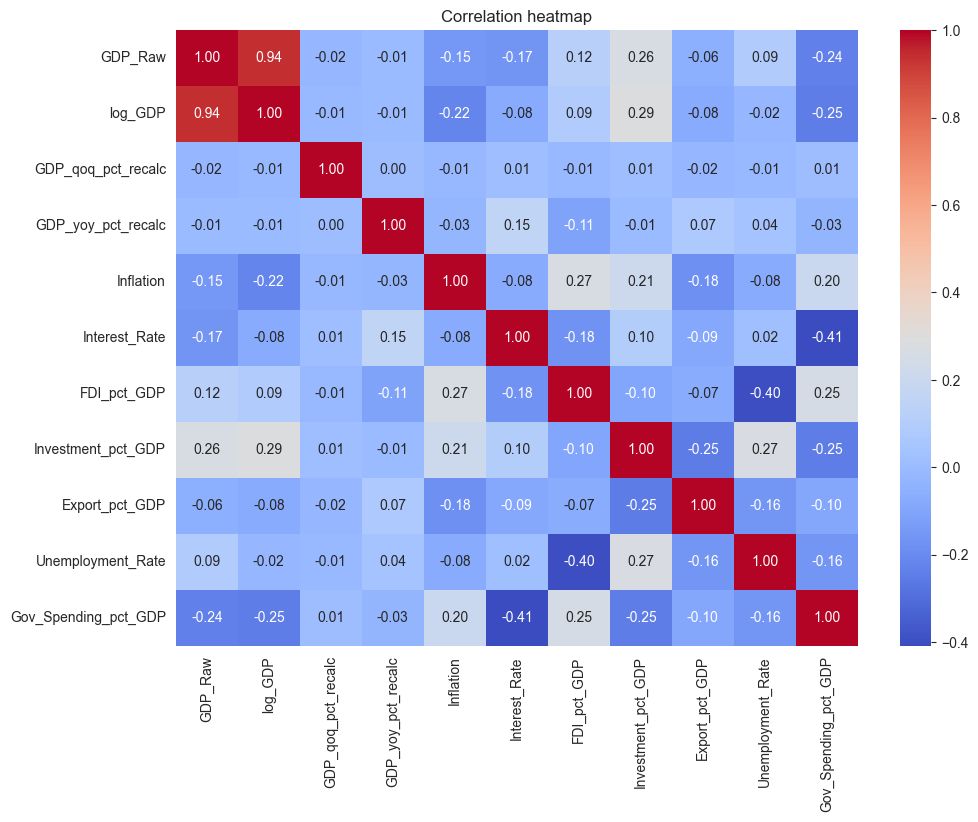

In [30]:
corr_cols = [
    "GDP_Raw", "log_GDP", "GDP_qoq_pct_recalc", "GDP_yoy_pct_recalc",
    "Inflation", "Interest_Rate", "FDI_pct_GDP", "Investment_pct_GDP",
    "Export_pct_GDP", "Unemployment_Rate", "Gov_Spending_pct_GDP"
]

corr_matrix = data[corr_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

## Kiểm tra yếu tố mùa vụ

Với dữ liệu theo quý, một số biến có thể có yếu tố mùa vụ.  
Ta dùng `seasonal_decompose` để tách chuỗi thành:

- Trend
- Seasonal
- Residual
- Observed

Nếu thành phần mùa vụ nhỏ, có thể chưa cần seasonal adjustment mạnh ở bước tiền xử lý.

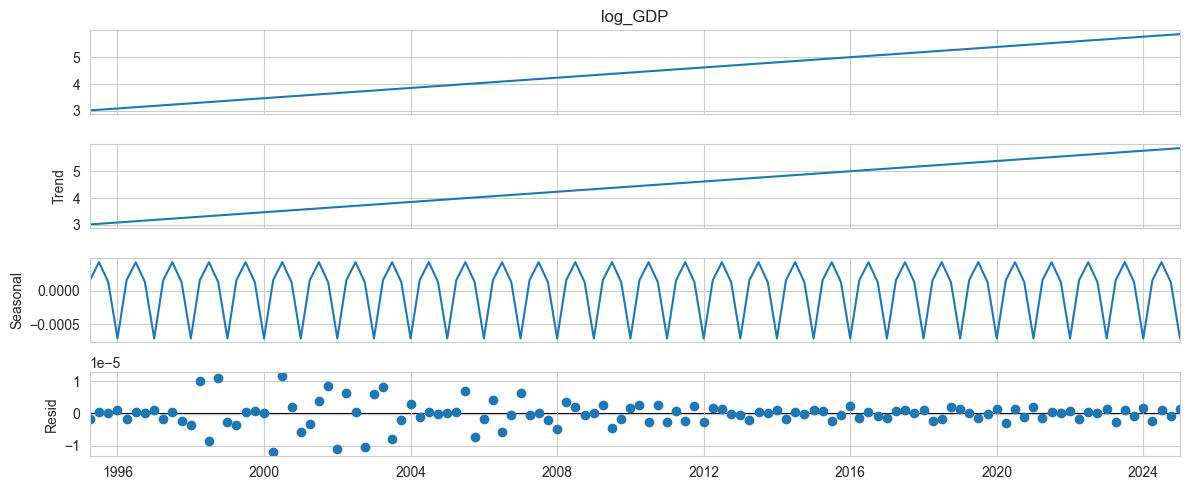

Seasonal strength (xấp xỉ): 0.0005164317710035466


In [31]:
decomp = seasonal_decompose(data["log_GDP"].dropna(), model="additive", period=4, extrapolate_trend="freq")
decomp.plot()
plt.show()

seasonal_strength = decomp.seasonal.std() / data["log_GDP"].std()
print("Seasonal strength (xấp xỉ):", seasonal_strength)

## Chuẩn hóa dữ liệu cho mô hình machine learning

Các biến vĩ mô thường có thang đo rất khác nhau.  
Ví dụ:
- lạm phát chỉ vài phần trăm
- đầu tư/GDP hoặc xuất khẩu/GDP có thể lớn hơn nhiều

Vì vậy, với các mô hình machine learning như:
- XGBoost
- LSTM
- MLP
- SVR

ta có thể chuẩn hóa dữ liệu bằng `StandardScaler`.

Lưu ý:
- Bước này hữu ích cho ML
- Không nhất thiết dùng cho ARIMA hoặc SARIMAX

In [32]:
feature_cols = [
    "Inflation", "Interest_Rate", "FDI_pct_GDP", "Investment_pct_GDP",
    "Export_pct_GDP", "Unemployment_Rate", "Gov_Spending_pct_GDP"
]

scaler = StandardScaler()
scaled_values = scaler.fit_transform(data[feature_cols])

scaled_df = pd.DataFrame(
    scaled_values,
    index=data.index,
    columns=[f"{c}_scaled" for c in feature_cols]
)

processed = pd.concat([data, scaled_df], axis=1)

display(processed.head())

,GDP_Raw,Inflation,Interest_Rate,FDI_pct_GDP,Investment_pct_GDP,Export_pct_GDP,Unemployment_Rate,Gov_Spending_pct_GDP,GDP_Growth,log_GDP,...,Interest_Rate_lag2,log_GDP_diff1,log_GDP_diff4,Inflation_scaled,Interest_Rate_scaled,FDI_pct_GDP_scaled,Investment_pct_GDP_scaled,Export_pct_GDP_scaled,Unemployment_Rate_scaled,Gov_Spending_pct_GDP_scaled
1995-04-01,20.50,3.537,3.577,5.488,31.137,76.943,2.524,20.262,2.500,3.020425,...,NaN,NaN,NaN,0.326335,-1.260364,0.923785,0.458664,-0.749002,-0.558848,1.011468
1995-07-01,21.00,3.825,3.471,5.075,31.661,78.188,2.686,19.803,2.439,3.044522,...,NaN,0.024098,NaN,0.952446,-1.356629,0.437938,0.663114,-0.544521,-0.052368,0.756824
1995-10-01,21.50,4.113,3.366,4.662,32.185,79.433,2.847,19.345,2.381,3.068053,...,3.577,0.023530,NaN,1.578557,-1.451985,-0.047908,0.867564,-0.340040,0.450987,0.502734
1996-01-01,22.00,4.401,3.260,4.249,32.710,80.678,3.008,18.886,2.326,3.091042,...,3.471,0.022990,NaN,2.204668,-1.548249,-0.533755,1.072404,-0.135559,0.954341,0.248089
1996-04-01,22.55,4.292,4.144,4.182,32.017,83.121,3.042,18.842,2.500,3.115735,...,3.366,0.024693,0.09531,1.967702,-0.745442,-0.612573,0.802015,0.265683,1.060639,0.223679


## Lưu bộ dữ liệu đã xử lý

Sau khi hoàn thành các bước tiền xử lý, ta xuất bộ dữ liệu mới để dùng cho:
- mô hình dự báo
- hồi quy
- machine learning
- báo cáo kết quả

File xuất ra sẽ bao gồm:
- dữ liệu gốc đã làm sạch
- `log_GDP`
- các biến tăng trưởng
- các biến trễ
- các biến đã scale cho ML

In [33]:
OUTPUT_PATH = "secondary_data_processed.csv"
processed.to_csv(OUTPUT_PATH, index=True)

print("Đã lưu:", OUTPUT_PATH)
display(processed.tail())

Đã lưu: secondary_data_processed.csv


,GDP_Raw,Inflation,Interest_Rate,FDI_pct_GDP,Investment_pct_GDP,Export_pct_GDP,Unemployment_Rate,Gov_Spending_pct_GDP,GDP_Growth,log_GDP,...,Interest_Rate_lag2,log_GDP_diff1,log_GDP_diff4,Inflation_scaled,Interest_Rate_scaled,FDI_pct_GDP_scaled,Investment_pct_GDP_scaled,Export_pct_GDP_scaled,Unemployment_Rate_scaled,Gov_Spending_pct_GDP_scaled
2024-01-01,317.262,2.593,4.555,5.496,28.180,82.236,2.387,16.661,2.326,5.759728,...,4.428,0.022991,0.09531,-1.725918,-0.372191,0.933196,-0.695075,0.120329,-0.987168,-0.986300
2024-04-01,325.193,2.873,4.437,5.538,27.660,85.338,2.538,16.815,2.500,5.784419,...,4.491,0.024691,0.09531,-1.117199,-0.479353,0.982604,-0.897965,0.629806,-0.515078,-0.900864
2024-07-01,333.125,3.154,4.320,5.580,27.140,88.439,2.688,16.969,2.439,5.808518,...,4.555,0.024099,0.09531,-0.506306,-0.585607,1.032012,-1.100854,1.139119,-0.046115,-0.815427
2024-10-01,341.056,3.435,4.203,5.621,26.620,91.540,2.839,17.124,2.381,5.832047,...,4.437,0.023529,0.09531,0.104587,-0.691861,1.080244,-1.303744,1.648432,0.425975,-0.729436
2025-01-01,348.988,3.715,4.085,5.663,26.101,94.641,2.990,17.278,2.326,5.855038,...,4.320,0.022991,0.09531,0.713306,-0.799023,1.129652,-1.506243,2.157745,0.898065,-0.644000


## Nhóm 8 - Toán Kinh tế 65, Khoa học dữ liệu trong Kinh tế và Kinh doanh.